In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv('../data/cleaned_crime_records.csv')

In [3]:
df = df.sample(n=100000, random_state=42)

In [4]:
df1=pd.read_csv('../data/Crimes_-_2001_to_Present_20260406.csv')

In [5]:
df1.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='str')

In [6]:
df1['Location Description'].value_counts()

Location Description
STREET                145029
APARTMENT             105873
RESIDENCE              64663
SIDEWALK               27777
SMALL RETAIL STORE     20583
                       ...  
GANGWAY                    2
NEWSSTAND                  2
RIVER BANK                 1
CHA STAIRWELL              1
LIQUOR STORE               1
Name: count, Length: 134, dtype: int64

In [7]:
df.describe()

,ID,District,Ward,Community Area,Latitude,Longitude,hour,month,year
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,1.373798e+07,11.232440,23.113340,36.352990,41.846388,-87.668086,12.503040,6.516750,2024.66168
std,6.591733e+05,7.074774,13.923197,21.511449,0.086371,0.059067,6.832175,3.323289,0.64582
min,2.800500e+04,1.000000,1.000000,1.000000,41.644608,-87.931147,0.000000,1.000000,2024.00000
25%,1.357401e+07,5.000000,10.000000,22.000000,41.772387,-87.709268,8.000000,4.000000,2024.00000
50%,1.376313e+07,10.000000,23.000000,32.000000,41.864184,-87.660613,13.000000,7.000000,2025.00000
75%,1.395689e+07,17.000000,34.000000,53.000000,41.909147,-87.626751,18.000000,9.000000,2025.00000
max,1.415541e+07,31.000000,50.000000,77.000000,42.022536,-87.524532,23.000000,12.000000,2026.00000


In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 104241 to 240408
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    100000 non-null  int64  
 1   Date                  100000 non-null  str    
 2   Primary Type          100000 non-null  str    
 3   Description           100000 non-null  str    
 4   Location Description  100000 non-null  str    
 5   Arrest                100000 non-null  bool   
 6   Domestic              100000 non-null  bool   
 7   District              100000 non-null  int64  
 8   Ward                  100000 non-null  float64
 9   Community Area        100000 non-null  float64
 10  Latitude              100000 non-null  float64
 11  Longitude             100000 non-null  float64
 12  hour                  100000 non-null  int64  
 13  day                   100000 non-null  str    
 14  month                 100000 non-null  int64  
 15  year       

In [9]:
df['Community Area'].value_counts()

Community Area
25.0    4966
8.0     4502
28.0    4362
32.0    3723
43.0    3319
        ... 
37.0     279
12.0     208
74.0     208
9.0      118
47.0     117
Name: count, Length: 77, dtype: int64

In [10]:
df['Arrest']=df['Arrest'].astype('int32')

In [11]:
df['Domestic']=df['Domestic'].astype('int32')

In [12]:
df['Ward']=df['Ward'].astype('int32')

In [13]:
df['Community Area']=df['Community Area'].astype('int32')

In [14]:
crime_severity = {
    'NON-CRIMINAL': 1,

    'LIQUOR LAW VIOLATION': 2,
    'PUBLIC INDECENCY': 2,
    'GAMBLING': 2,
    'OBSCENITY': 2,

    'NARCOTICS': 3,
    'OTHER NARCOTIC VIOLATION': 3,
    'PROSTITUTION': 3,
    'CONCEALED CARRY LICENSE VIOLATION': 3,
    'PUBLIC PEACE VIOLATION': 3,

    'CRIMINAL TRESPASS': 4,
    'INTERFERENCE WITH PUBLIC OFFICER': 4,
    'INTIMIDATION': 4,
    'STALKING': 4,
    'DECEPTIVE PRACTICE': 4,
    'OTHER OFFENSE': 4,

    'THEFT': 5,
    'BURGLARY': 5,
    'MOTOR VEHICLE THEFT': 5,
    'CRIMINAL DAMAGE': 5,

    'BATTERY': 6,
    'ASSAULT': 6,
    'WEAPONS VIOLATION': 6,
    'ROBBERY': 6,

    'SEX OFFENSE': 7,
    'OFFENSE INVOLVING CHILDREN': 7,

    'ARSON': 8,
    'CRIMINAL SEXUAL ASSAULT': 8,
    'KIDNAPPING': 8,

    'HUMAN TRAFFICKING': 9,

    'HOMICIDE': 10
}

In [15]:
df['crime_severity'] = df['Primary Type'].map(crime_severity)

In [16]:
df['crime_severity'].value_counts()

crime_severity
5     45968
6     32802
4     15443
3      3422
7      1156
8       874
10      207
2       118
9        10
Name: count, dtype: int64

In [17]:
df[df['crime_severity'].isna()]['Primary Type'].unique()

<ArrowStringArray>
[]
Length: 0, dtype: str

In [18]:
day_map={
        'Sunday':0,
        'Monday':1,
        'Tuesday':2,
        'Wednesday':3,
        'Thursday':4,
        'Friday':5,
        'Saturday':6,
    }
df['day']=df['day'].replace(day_map)

In [19]:
features=df[['Latitude', 'Longitude',
'Ward','Community Area','Domestic','Arrest',
'hour', 'day', 'month', 'crime_severity']]

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

In [21]:
from sklearn.decomposition import PCA

pca = PCA(.70)
pca.fit(X)

print(pca.explained_variance_ratio_)

[0.26977704 0.1243772  0.10571232 0.10223803 0.09961792]


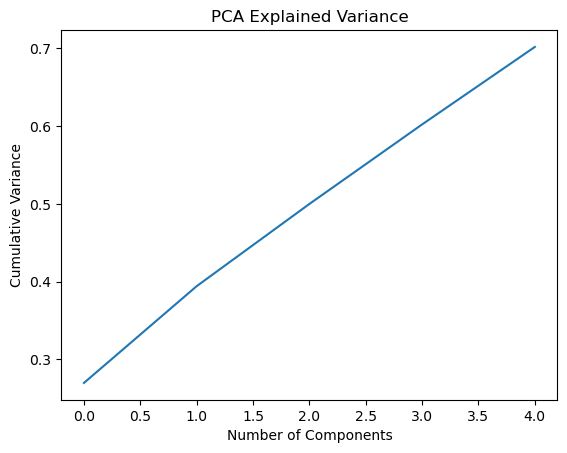

In [22]:
import matplotlib.pyplot as plt
import numpy as np

explained = np.cumsum(pca.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()

In [23]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]
df['pca3'] = X_pca[:,2]

In [29]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"
fig = px.scatter(
    df,
    x='pca2',
    y='pca1',
    color='cluster'
)

fig.show()

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['ID', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude', 'Longitude', 'hour', 'day', 'month', 'year', 'weekend', 'crime_severity', 'pca1', 'pca2', 'pca3'] but received: cluster

In [ ]:
features=df[['Latitude', 'Longitude',
'Ward','Community Area','Domestic','Arrest',
'hour', 'day', 'month', 'crime_severity']]

In [25]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X)

/Users/rishabh/miniconda3/envs/ML_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


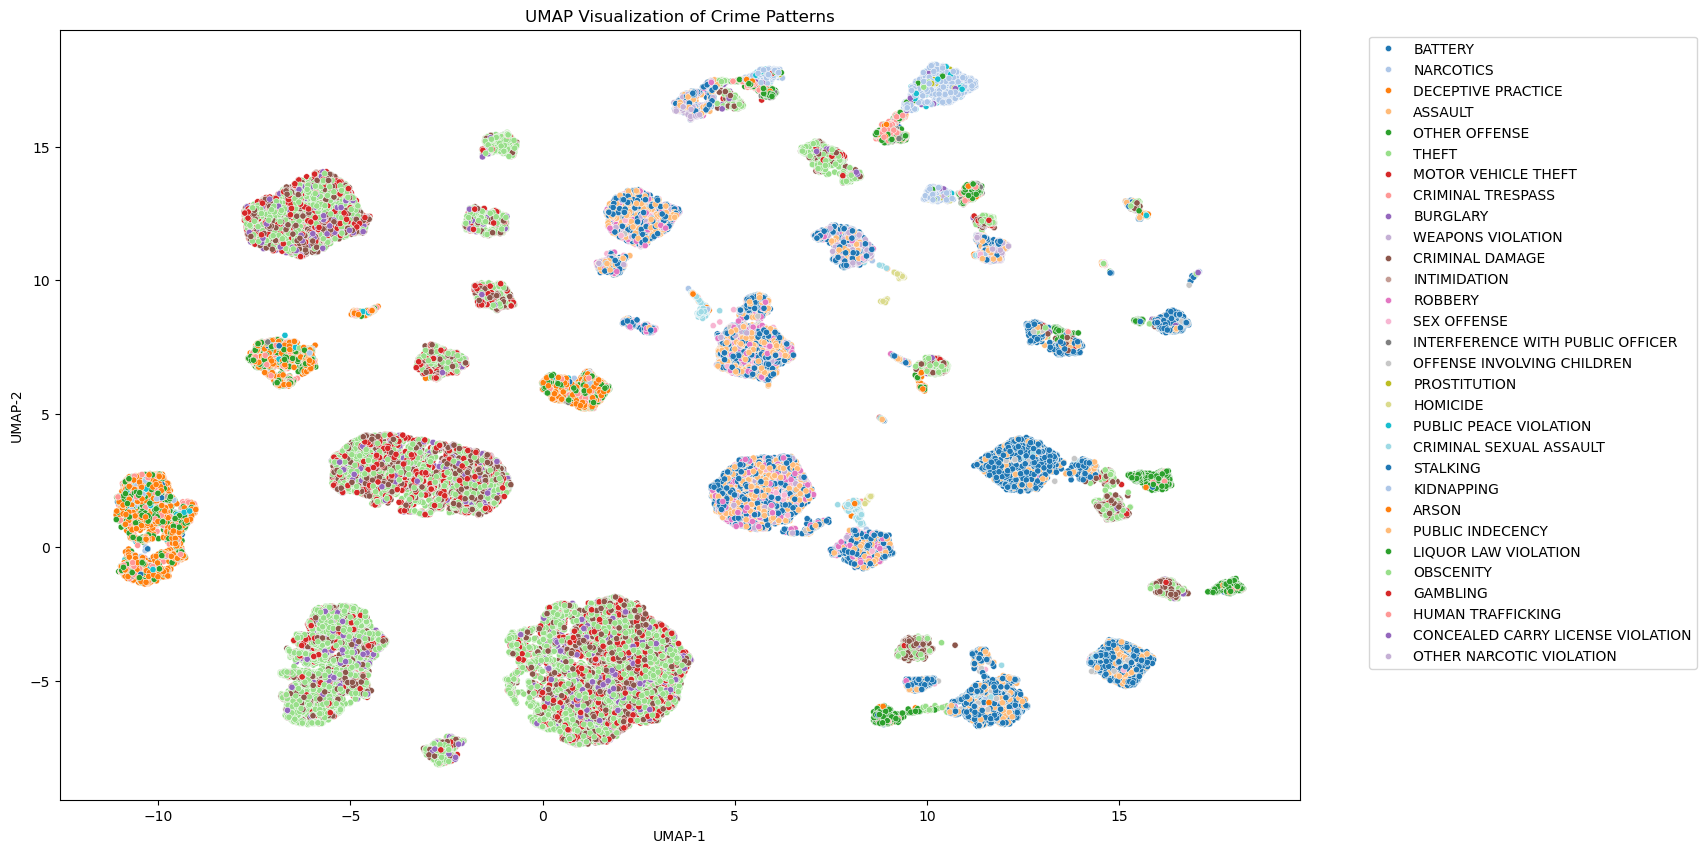

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df['Primary Type'],
    palette='tab20',
    s=20
)

plt.title('UMAP Visualization of Crime Patterns')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.legend(bbox_to_anchor=(1.05,1))
plt.show()